In [23]:
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [24]:
load_dotenv()

True

In [25]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.7
)

In [26]:
loader = PyPDFLoader("NITESH_CV_1.pdf")
docs = loader.load()

In [27]:
len(docs)

1

In [28]:
docs

[Document(metadata={'producer': 'pdfTeX-1.40.27', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-06-13T15:23:55+00:00', 'author': '', 'keywords': '', 'moddate': '2026-06-13T15:23:55+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) kpathsea version 6.4.1', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'NITESH_CV_1.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='NITESH KUMAR MISHRA\n♂¶ap-¶arker-altNew Delhi, India\n♂phone+91 7982765889✉mishranitesh45176@gmail.com/linkedinLinkedIn/githubGitHub/gl⌢bePortfolio\nSUMMARY\nFull Stack Engineer experienced in building production-ready web applications using Next.js, TypeScript, Post-\ngreSQL, and modern cloud technologies. Skilled in designing secure backend systems, scalable APIs, authenti-\ncation workflows, and automated deployment pipelines.\nSKILLS\nLanguages:TypeScript, JavaScript, Python, C++\nFrontend:Next.js, React.js, Tailwind CSS\nBackend:Node.js, tR

In [29]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [30]:
len(chunks)

3

In [31]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
vector_store = FAISS.from_documents(chunks, embeddings)
vector_store.save_local("faiss_index")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [32]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [33]:
ans = retriever.invoke("what is in this pdf?")
ans

[Document(id='30915c39-df9a-40c7-a0b9-eb23e5044ab6', metadata={'producer': 'pdfTeX-1.40.27', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-06-13T15:23:55+00:00', 'author': '', 'keywords': '', 'moddate': '2026-06-13T15:23:55+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) kpathsea version 6.4.1', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'NITESH_CV_1.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='•Developed responsive interfaces using Next.js and TypeScript with reusable components.\nTaskora – Workflow PlatformLive — GitHub\nTech Stack: MERN Stack\n•Developed a role-based task management platform with JWT authentication and authorization.\n•Designed REST APIs for managing users, tasks, and workflow operations.\n•Implemented task lifecycle management with status tracking and validation.\nACHIEVEMENTS & CERTIFICATIONS\n•Top 50 finalist among 5000+ participants in HacToImpact Hackathon at IIIT Delh

In [34]:
@tool
def rag_tool(query: str)-> str:
    """
    Retrieve relevant information from the PDF document.

    Use this tool when the user asks factual or conceptual questions
    that may be answered using the stored PDF documents.

    Args:
        query: The question or search query used to retriever PDF content.
    """

    documents = retriever.invoke(query)

    if not documents:
        return "No relevant information was found in the PDF."

    formatted_documents = []

    for index, document in enumerate(documents,  start=1):
        source = document.metadata.get("source","Unknown source")
        page = document.metadata.get("page","Unknown page")

        formatted_documents.append(
            f"Document {index}\n"
            f"Source: {source}\n"
            f"Page: {page}\n"
            f"Content: {document.page_content}"
        )

    return "\n\n".join(formatted_documents)

In [35]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [36]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [37]:
# graph nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

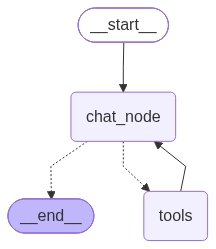

In [38]:
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)
graph.add_edge(START, "chat_node")

graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools","chat_node")
chatbot = graph.compile()

chatbot

In [39]:
result = chatbot.invoke({"messages":[HumanMessage(content="Hello")]})

print(result["messages"][-1].content)

Hello! How can I help you today?


In [41]:
result = chatbot.invoke({"messages":[HumanMessage(content="Tell me what is in the pdf")]})

print(result["messages"][-1].content)

Below is a concise overview of the PDF you uploaded ( **NITESH KUMAR MISHRA – Curriculum Vitae** ). It is a single‑page résumé that highlights the candidate’s background, technical expertise, education, projects, and achievements.

---

## 1. Contact & Personal Details
| Item | Value |
|------|-------|
| **Name** | Nitesh Kumar Mishra |
| **Location** | New Delhi, India |
| **Phone** | +91 798 276 5889 |
| **Email** | mishranitesh45176@gmail.com |
| **LinkedIn / GitHub / Portfolio** | Links provided (icons in the original PDF) |

---

## 2. Professional Summary
- **Role:** Full‑Stack Engineer.  
- **Core strength:** Building production‑ready web applications with **Next.js**, **TypeScript**, **PostgreSQL**, and modern cloud tooling.  
- **Key capabilities:** Secure backend design, scalable APIs, authentication/authorization flows, and automated CI/CD pipelines.

---

## 3. Technical Skills
| Category | Tools / Technologies |
|----------|----------------------|
| **Languages** | TypeScr